# 01. 데이터 탐색 및 고객 이탈 요인 분석 (EDA)

**프로젝트:** 구독형 이커머스 멤버십 고객 이탈 예측 및 세분화
** 개인팀(황채원) 진행**
---
### 분석 목표
1. 고객 데이터 품질 점검 및 전처리 (결측치/이상치)
2. 이탈 고객 vs 유지 고객의 행동 차이 규명
3. 이탈에 영향을 주는 핵심 변수(드라이버) 도출 → 모델링 피처 선정 근거 마련

> 본 데이터는 **개인정보·저작권 이슈가 없는 합성(synthetic) 데이터**로,
> 실제 구독 커머스의 행동 패턴(최근성·구매빈도·만족도·자동결제 등)을 모사하여 생성하였다.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'   # macOS 한글 폰트
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

df = pd.read_csv('사용 데이터/고객_구독_데이터.csv')
print('데이터 shape:', df.shape)
df.head()

데이터 shape: (9000, 20)


,고객ID,성별,연령,지역,가입채널,가입개월수,요금제,월요금,결제수단,자동결제여부,월평균로그인수,월평균주문수,평균주문금액,누적결제금액,최근주문경과일,CS문의수,만족도점수,쿠폰사용률,모바일사용비중,이탈여부
0,C100000,남,44,서울,SNS,30,Standard,19900,신용카드,1,14,1.1,34700,1145100,0,0,4.4,0.248,0.888,0
1,C100001,남,42,경기,검색광고,11,Premium,34900,체크카드,0,21,6.0,34500,2277000,18,2,4.0,0.322,0.802,0
2,C100002,남,34,부산,SNS,34,Basic,9900,간편결제,1,22,3.7,28600,3597900,0,0,3.9,0.294,0.918,0
3,C100003,남,28,인천,지인추천,13,Premium,34900,신용카드,1,11,3.2,34300,1426900,9,1,3.5,0.512,0.781,0
4,C100004,남,35,광주,검색광고,47,Basic,9900,간편결제,1,13,5.1,32000,7670400,85,1,1.9,0.600,0.764,1


## 1. 데이터 구조 및 기초 통계

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 20 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   고객ID     9000 non-null   object 
 1   성별       9000 non-null   object 
 2   연령       9000 non-null   int64  
 3   지역       9000 non-null   object 
 4   가입채널     9000 non-null   object 
 5   가입개월수    9000 non-null   int64  
 6   요금제      9000 non-null   object 
 7   월요금      9000 non-null   int64  
 8   결제수단     9000 non-null   object 
 9   자동결제여부   9000 non-null   int64  
 10  월평균로그인수  9000 non-null   int64  
 11  월평균주문수   9000 non-null   float64
 12  평균주문금액   9000 non-null   int64  
 13  누적결제금액   9000 non-null   int64  
 14  최근주문경과일  9000 non-null   int64  
 15  CS문의수    9000 non-null   int64  
 16  만족도점수    8640 non-null   float64
 17  쿠폰사용률    8730 non-null   float64
 18  모바일사용비중  8820 non-null   float64
 19  이탈여부     9000 non-null   int64  
dtypes: float64(4), int64(10), object(6)
memory usage: 1.

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
고객ID,9000,9000,C100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
성별,9000,2,여,4552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
연령,9000.0,NaN,NaN,NaN,38.257556,10.595551,19.0,31.0,38.0,45.0,75.0
지역,9000,8,서울,2435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
가입채널,9000,5,검색광고,2708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
가입개월수,9000.0,NaN,NaN,NaN,15.253778,10.233535,1.0,8.0,13.0,20.0,72.0
요금제,9000,3,Basic,4028,NaN,NaN,NaN,NaN,NaN,NaN,NaN
월요금,9000.0,NaN,NaN,NaN,18067.777778,9003.195193,9900.0,9900.0,19900.0,19900.0,34900.0
결제수단,9000,4,신용카드,4131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
자동결제여부,9000.0,NaN,NaN,NaN,0.677556,0.467438,0.0,0.0,1.0,1.0,1.0


## 2. 결측치 점검 및 처리
수치형 행동지표 일부에 결측이 존재한다. 분포 왜곡을 막기 위해 **중앙값**으로 대치한다.

In [4]:
na = df.isna().sum()
print(na[na>0])
for c in ['만족도점수','쿠폰사용률','모바일사용비중']:
    df[c] = df[c].fillna(df[c].median())
print('\n결측치 처리 후 총 결측:', int(df.isna().sum().sum()))

만족도점수      360
쿠폰사용률      270
모바일사용비중    180
dtype: int64

결측치 처리 후 총 결측: 0


## 3. 타깃 변수(이탈여부) 분포
이탈률 약 20% 수준의 **불균형(imbalanced)** 데이터로, 모델링 시 가중치/평가지표 선택에 유의해야 한다.

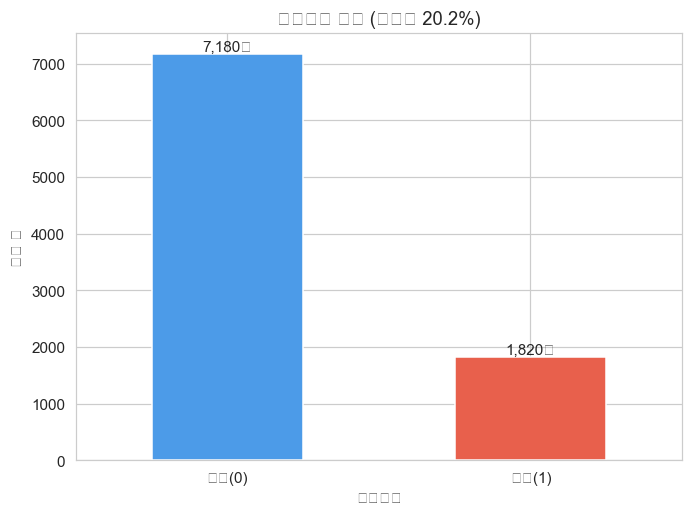

In [5]:
rate = df['이탈여부'].mean()
ax = df['이탈여부'].value_counts().sort_index().plot(kind='bar', color=['#4C9BE8','#E8604C'])
ax.set_xticklabels(['유지(0)','이탈(1)'], rotation=0)
for i,v in enumerate(df['이탈여부'].value_counts().sort_index()):
    ax.text(i, v+50, f'{v:,}명', ha='center')
plt.title(f'이탈여부 분포 (이탈률 {rate:.1%})'); plt.ylabel('고객 수'); plt.tight_layout(); plt.show()

## 4. 요금제 · 자동결제 여부에 따른 이탈률
계약 특성이 이탈과 강하게 연결되는지 확인한다.

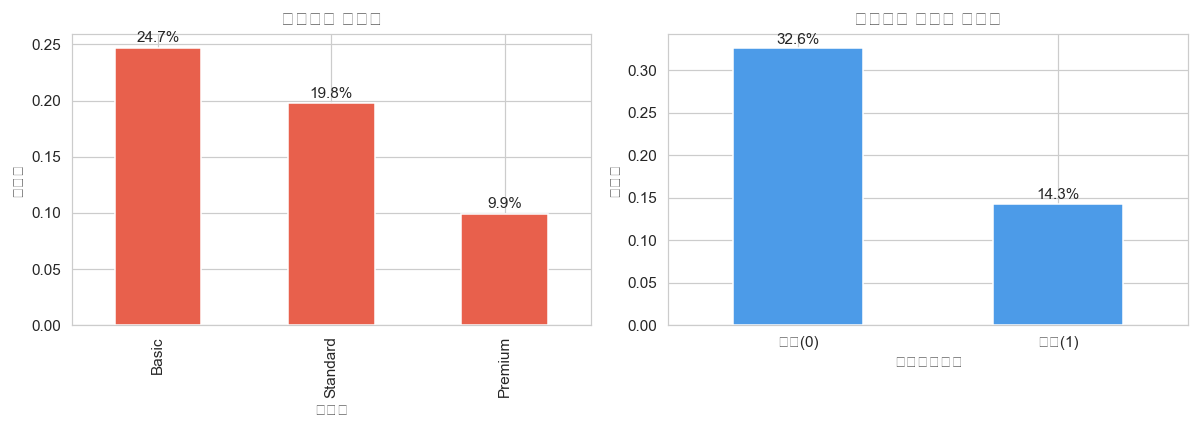

→ Basic 요금제 / 수동결제 고객의 이탈률이 뚜렷하게 높다.


In [6]:
fig, ax = plt.subplots(1,2, figsize=(11,4))
g1 = df.groupby('요금제')['이탈여부'].mean().reindex(['Basic','Standard','Premium'])
g1.plot(kind='bar', ax=ax[0], color='#E8604C')
ax[0].set_title('요금제별 이탈률'); ax[0].set_ylabel('이탈률')
for i,v in enumerate(g1): ax[0].text(i, v+0.005, f'{v:.1%}', ha='center')

g2 = df.groupby('자동결제여부')['이탈여부'].mean()
g2.plot(kind='bar', ax=ax[1], color='#4C9BE8')
ax[1].set_xticklabels(['수동(0)','자동(1)'], rotation=0)
ax[1].set_title('자동결제 여부별 이탈률'); ax[1].set_ylabel('이탈률')
for i,v in enumerate(g2): ax[1].text(i, v+0.005, f'{v:.1%}', ha='center')
plt.tight_layout(); plt.show()
print('→ Basic 요금제 / 수동결제 고객의 이탈률이 뚜렷하게 높다.')

## 5. 행동 지표 분포 비교 (이탈 vs 유지)
최근주문경과일·로그인수·만족도·가입개월수 분포를 그룹별로 비교한다.

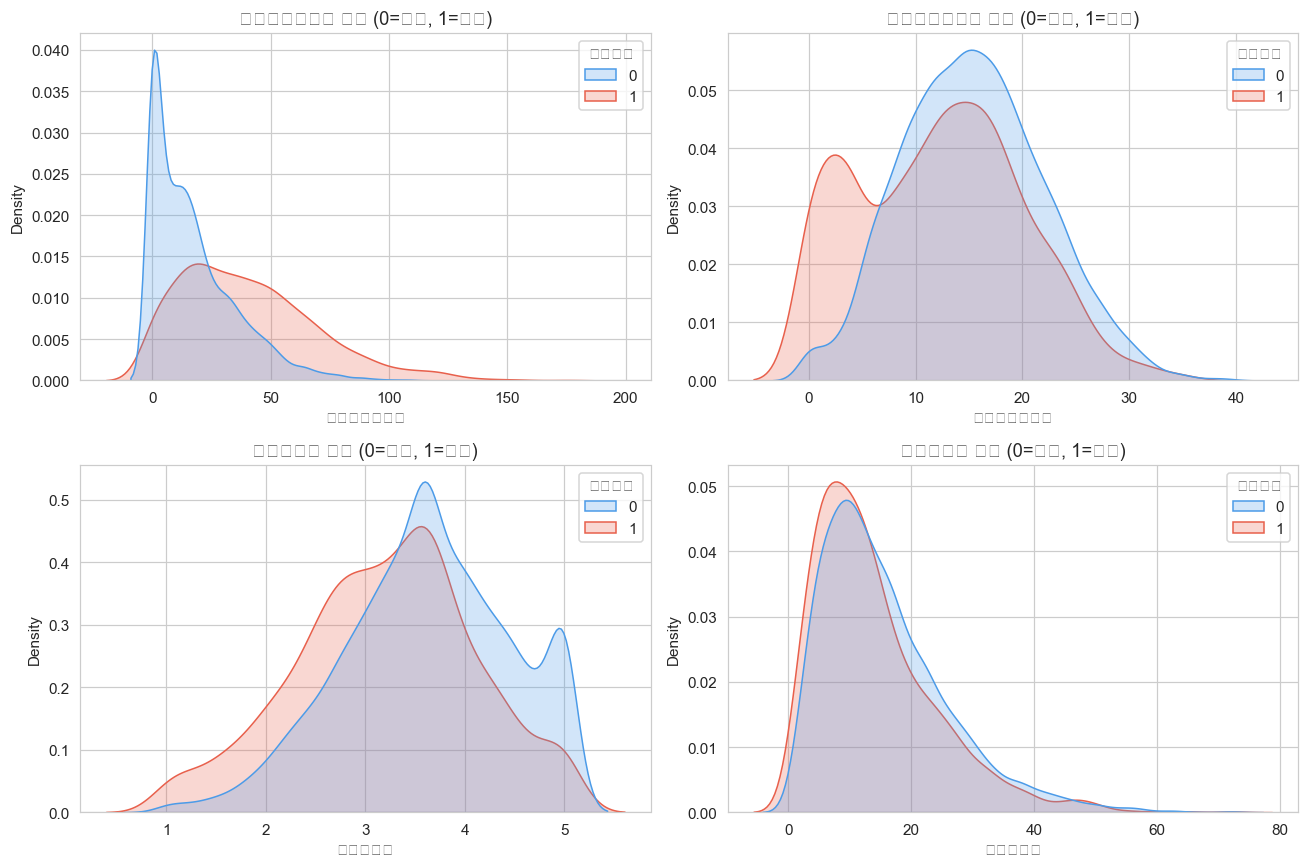

→ 이탈 고객은 최근주문경과일↑, 로그인수↓, 만족도↓, 가입개월수↓ 경향.


In [7]:
cols = ['최근주문경과일','월평균로그인수','만족도점수','가입개월수']
fig, axes = plt.subplots(2,2, figsize=(12,8))
for c, ax in zip(cols, axes.ravel()):
    sns.kdeplot(data=df, x=c, hue='이탈여부', fill=True, common_norm=False,
                palette={0:'#4C9BE8',1:'#E8604C'}, ax=ax)
    ax.set_title(f'{c} 분포 (0=유지, 1=이탈)')
plt.tight_layout(); plt.show()
print('→ 이탈 고객은 최근주문경과일↑, 로그인수↓, 만족도↓, 가입개월수↓ 경향.')

## 6. 수치형 변수 상관관계 히트맵

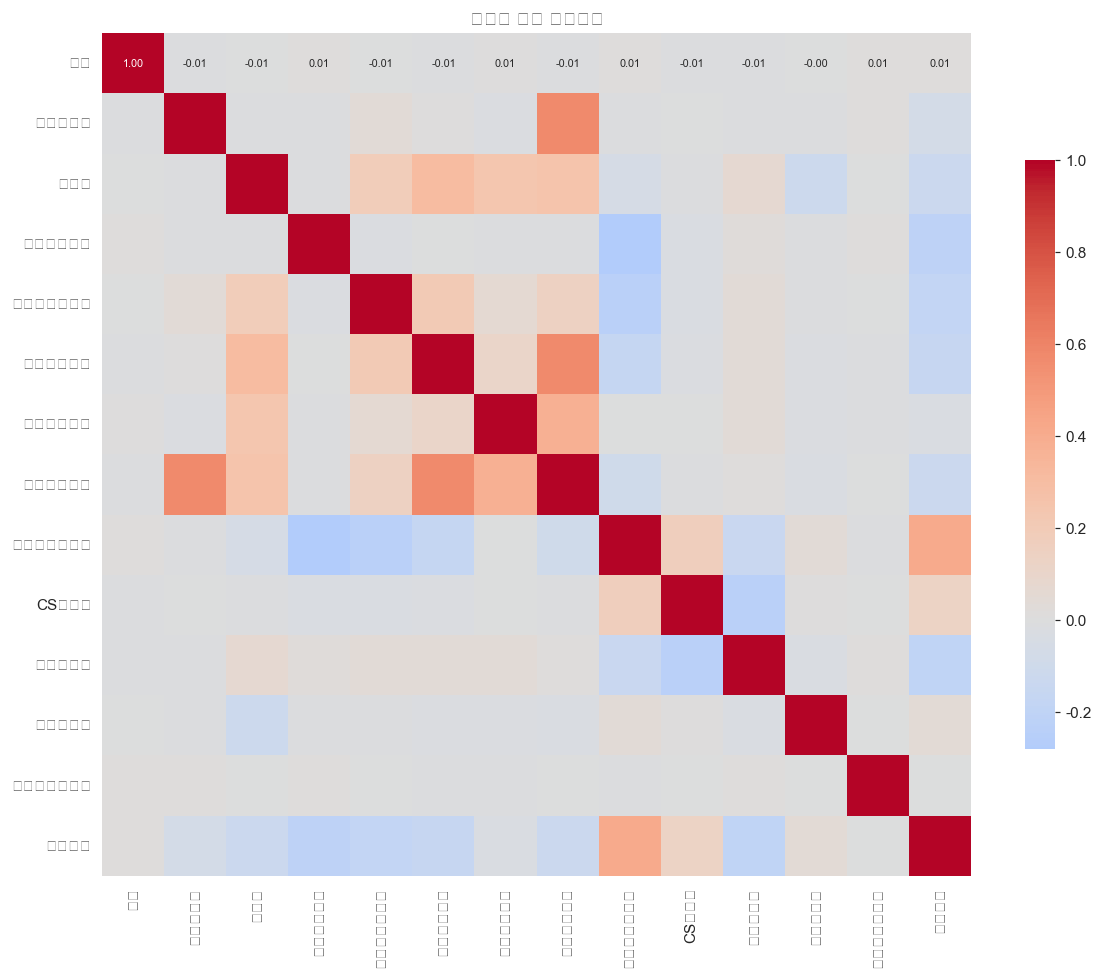

In [8]:
num = ['연령','가입개월수','월요금','자동결제여부','월평균로그인수','월평균주문수',
       '평균주문금액','누적결제금액','최근주문경과일','CS문의수','만족도점수',
       '쿠폰사용률','모바일사용비중','이탈여부']
plt.figure(figsize=(11,9))
sns.heatmap(df[num].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size':7}, cbar_kws={'shrink':0.7})
plt.title('수치형 변수 상관관계'); plt.tight_layout(); plt.show()

## 7. 이탈과의 상관계수 순위 (핵심 드라이버)

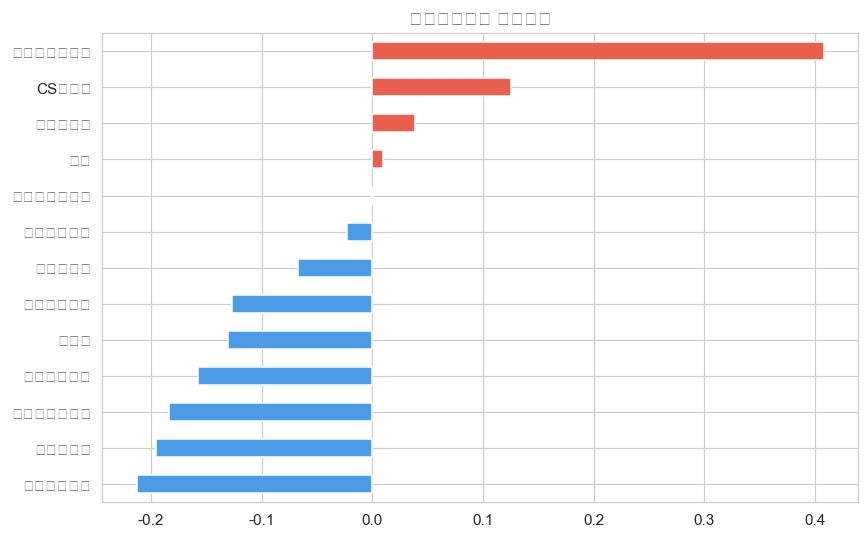

,이탈상관계수
자동결제여부,-0.213151
만족도점수,-0.195578
월평균로그인수,-0.183630
월평균주문수,-0.157370
월요금,-0.130603
누적결제금액,-0.127249
가입개월수,-0.067364
평균주문금액,-0.023184
모바일사용비중,0.000767
연령,0.009510


In [9]:
corr_churn = df[num].corr()['이탈여부'].drop('이탈여부').sort_values()
ax = corr_churn.plot(kind='barh', figsize=(8,5),
                     color=['#4C9BE8' if v<0 else '#E8604C' for v in corr_churn])
ax.set_title('이탈여부와의 상관계수'); plt.tight_layout(); plt.show()
corr_churn.to_frame('이탈상관계수')

## 8. EDA 요약 (Insight)

| 구분 | 발견 사항 |
|---|---|
| **최근성(Recency)** | 최근주문경과일이 길수록 이탈률 급증 — 가장 강한 양(+) 상관 |
| **인게이지먼트** | 월평균 로그인수·주문수가 낮은 고객일수록 이탈 |
| **계약 형태** | Basic 요금제, **수동결제(자동결제 해지)** 고객 이탈률 현저히 높음 |
| **충성도** | 가입개월수가 길수록(=오래된 고객) 이탈률 하락 |
| **만족/CS** | 만족도 낮고 CS문의 많은 고객 이탈 위험 ↑ |

➡ 위 변수들을 핵심 피처로 채택하여 이탈 예측 모델(노트북 03)과
   RFM 고객 세분화(노트북 02)에 활용한다.